# Setup

The following cell sets up everything necessary to train the GCN.

In [ ]:
# Get contyent from drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. If not then pull latest
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# Install project. Need to do this after a fresh clone
!pip install -e . --quiet

# Copy data to local storage for faster access
if not os.path.exists("/content/graphs"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs /content/graphs
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# Check that graphs, participants and results are all being stored where is expected
from agnn.paths import get_graphs_root, get_participants_tsv, get_results_root
print(f"Graphs: {get_graphs_root()}")
print(f"Participants: {get_participants_tsv()}")
print(f"Results: {get_results_root()}")

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
Graphs: /content/graphs
Participants: /content/participants.tsv
Results: /content/drive/MyDrive/alzheimers-gnn-data/results
GPU: Tesla T4


Install torch geometric. Do it quietly so as not to clutter up notebook

In [ ]:
!pip install torch-geometric --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00


Test MultiBandGCN is configured correctly

In [ ]:
from torch_geometric.data import Data, Batch
from agnn.gnn.model import MultiBandGCN

# Create dummy delta and alpha2 graphs
delta = Data(x=torch.rand(125, 2), edge_index=torch.randint(0, 125, (2, 3100)), edge_attr=torch.rand(3100, 1), y=torch.tensor([1]))
alpha2 = Data(x=torch.rand(125, 2), edge_index=torch.randint(0, 125, (2, 3100)), edge_attr=torch.rand(3100, 1), y=torch.tensor([1]))

# Batch them. Simulate batch size 2.
delta_batch = Batch.from_data_list([delta, delta])
alpha2_batch = Batch.from_data_list([alpha2, alpha2])

# Instantiate and forward
model = MultiBandGCN()
logits = model(delta_batch, alpha2_batch)

print(f"Output shape: {logits.shape}")  # Should be (2, 2) if it worked properly
print(f"Sample logits: {logits}")

Output shape: torch.Size([2, 2])
Sample logits: tensor([[0.0586, 0.1804],
        [0.0548, 0.1739]], grad_fn=<AddmmBackward0>)


Test load_subject_graphs() and pair_by_epochs() functions are working properly using the first five skeleton subjects

In [ ]:
from agnn.paths import get_graphs_root
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits

# Load the first 5 subjects
subjects = ["sub-01", "sub-02", "sub-03", "sub-04", "sub-05"]
graphs = load_subject_graphs(subjects, get_graphs_root())
print(f"Total graphs: {len(graphs)}")

# Pair them
pairs = pair_by_epoch(graphs)
print(f"Total pairs: {len(pairs)}")
print(f"Labels: {set(p[2] for p in pairs)}")

Total graphs: 888
Total pairs: 444
Labels: {0}


Total graphs being 888 and total pairs being 444 looks correct.

Test that the collate_pairs function is working

In [ ]:
from torch.utils.data import DataLoader
from agnn.gnn.data import GraphPairDataset, collate_pairs

# Wrap the pairs list in a PyTorch Dataset so DataLoader can iterate over it
dataset = GraphPairDataset(pairs)
loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_pairs)

# Get the first batch to check catching and collation is working properly.
delta_batch, alpha2_batch, labels = next(iter(loader))
print(f"Delta batch: {delta_batch}")
print(f"Alpha2 batch: {alpha2_batch}")
print(f"Labels: {labels}")
print(f"Labels shape: {labels.shape}")

Delta batch: DataBatch(x=[500, 2], edge_index=[2, 12400], edge_attr=[12400, 1], subject_id=[4], epoch_idx=[4], band=[4], y=[4], batch=[500], ptr=[5])
Alpha2 batch: DataBatch(x=[500, 2], edge_index=[2, 12400], edge_attr=[12400, 1], subject_id=[4], epoch_idx=[4], band=[4], y=[4], batch=[500], ptr=[5])
Labels: tensor([0, 0, 0, 0])
Labels shape: torch.Size([4])


Outputs are all looking as expected.

Check that the model is consuming real batched data correctly.

In [ ]:
from agnn.gnn.model import MultiBandGCN

# Set model to eval mode and run it on the batched data
model = MultiBandGCN()
model.eval()

# This is a diagnostic forwrad pass so no gradient tracking needed
with torch.no_grad():
    logits = model(delta_batch, alpha2_batch)

print(f"Logits shape: {logits.shape}") # Should see output shape (4, 2) because it matches 4 samples x 2 classes
print(f"Sample logits: {logits}")

Logits shape: torch.Size([4, 2])
Sample logits: tensor([[-0.1736,  0.0663],
        [-0.1738,  0.0674],
        [-0.1736,  0.0657],
        [-0.1740,  0.0675]])


Test that the training code is working correctly

In [ ]:
import torch
from agnn.paths import get_graphs_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Set seed and switch to cuda if its available
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Take a balanced sample. This one contains 15 subjects, 6 non carriers and 9 carriers
non_carriers = ["sub-01", "sub-02", "sub-03", "sub-04", "sub-05", "sub-06"]
carriers = ["sub-32", "sub-33", "sub-34", "sub-35", "sub-36", "sub-37", "sub-38", "sub-39", "sub-40"]
subjects = non_carriers + carriers

# Load graph .pt files for the sample and pair delta with alpha-2 by (subject, epoch)
graphs = load_subject_graphs(subjects, get_graphs_root())
pairs = pair_by_epoch(graphs)
n_pos = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}, positive class: {n_pos}/{len(pairs)} = {n_pos/len(pairs):.2%}")

# Create CV splits. Chose fold 0 as a smoke test
splits = make_cv_splits(pairs, n_folds=3, seed=42)  # 3 folds so should be 5 subjects per fold
train_idx, val_idx = splits[0]

# Use the defensive function to check that no subject appears in train and val
verify_no_subject_leakage(pairs, train_idx, val_idx)

# Check fold has both classes
train_labels = [pairs[i][2] for i in train_idx]
val_labels = [pairs[i][2] for i in val_idx]
print(f"Train: {sum(train_labels)}/{len(train_labels)} positive")
print(f"Val: {sum(val_labels)}/{len(val_labels)} positive")

# Build the train and val loaders for the chosen fold
train_loader = make_dataloader(pairs, train_idx, batch_size=32, shuffle=True)
val_loader = make_dataloader(pairs, val_idx, batch_size=32, shuffle=False)

# Fresh model on the target device
model = MultiBandGCN().to(device)

# Set up a short training config for the purposes of running a smoke test
config = {"learning_rate": 0.001, "weight_decay": 0.0001, "epochs": 10, "patience": 20, "class_weights": [1.5, 1.0]}

# Train one fold end to end and report best validation AUC
result = train_fold(model, train_loader, val_loader, config, device, verbose=True)
print(f"\nBest AUC: {result['best_auc']:.4f} at epoch {result['best_epoch']}")

Total pairs: 1291, positive class: 757/1291 = 58.64%
Train: 489/844 positive
Val: 268/447 positive
Epoch   1/10: train_loss=0.6909, val_loss=0.7067, val_auc=0.5513
Epoch   2/10: train_loss=0.6831, val_loss=0.7049, val_auc=0.5513
Epoch   3/10: train_loss=0.6680, val_loss=0.7045, val_auc=0.5519
Epoch   4/10: train_loss=0.6458, val_loss=0.7146, val_auc=0.5520
Epoch   5/10: train_loss=0.6273, val_loss=0.7287, val_auc=0.5517
Epoch   6/10: train_loss=0.6223, val_loss=0.7464, val_auc=0.5522
Epoch   7/10: train_loss=0.6243, val_loss=0.7496, val_auc=0.5522
Epoch   8/10: train_loss=0.6252, val_loss=0.7598, val_auc=0.5525
Epoch   9/10: train_loss=0.6268, val_loss=0.7450, val_auc=0.5514
Epoch  10/10: train_loss=0.6232, val_loss=0.7560, val_auc=0.5524

Best AUC: 0.5525 at epoch 8


All appears to be in working order

## Train the Model

In [ ]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_graphs_root, get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cpu":
    print("WARNING: running on CPU. Training will be slow.")

Device: cuda


Set up configuration, ie define hyperparameters

In [ ]:
config = {
    # Model hyperparameters
    "hidden_channels": 64,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.5,

    # Training hyperparameters
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 32,
    "epochs": 200,
    "patience": 20,
    "class_weights": [1.5, 1.0],  # non-carrier (minority) to carrier (majority)

    # Cross-validation
    "n_folds": 5,
    "seed": 42,
}

# Print the config to check everything is looking right
print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  hidden_channels: 64
  embedding_dim: 32
  mlp_hidden: 32
  dropout: 0.5
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 32
  epochs: 200
  patience: 20
  class_weights: [1.5, 1.0]
  n_folds: 5
  seed: 42


Load and pair all of the subjects

In [ ]:
# Find all subject folders in the graphs directory
graphs_root = get_graphs_root()
subjects = sorted([d.name for d in graphs_root.iterdir() if d.is_dir()])
print(f"Found {len(subjects)} subjects at {graphs_root}")

# Load and pair all the graphs
graphs = load_subject_graphs(subjects, graphs_root)
pairs = pair_by_epoch(graphs)

# Check the cohort summary
n_positive = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Found 77 subjects at /content/graphs
Total pairs: 6653
Positive class (carriers): 3956 (59.5%)
Negative class (non-carriers): 2697 (40.5%)


Pre-CV diagnostic. Single train/validation split

Before running the full five-fold CV loop below, it's important to train the model once on a single held out validation split and look at the loss and AUC curves across epochs. It's a quick sanity check of basic training dynamics (is model learning at all, overfitting, plateauing, etc) before committing to the more computationally intensive 5x cost of full cross validation. Will determine if it's worth moving on to full CV by these curves.

The split used here is just a fold 0 of a 5-fold, subject grouped, stratified split 9same splitting logic used for full CV loop) so composition represents what the CV loop will see. No loop here, it's just run once.

In [ ]:
# Create a results directory for this diagnostic run, kept separate from the main CV run
diag_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
diag_dir = get_results_root() / f"prediagnostic_{diag_timestamp}"
diag_dir.mkdir(parents=True, exist_ok=True)
print(f"Pre-CV diagnostic results will save to: {diag_dir}")

# Build a single train/val split using the same grouped, stratified logic as the CV folds.
# This is just fold 0 of a 5-fold split, used once rather than in a loop, so the split
# composition is representative of what the full CV loop below will use.
set_seed(config["seed"])
diag_splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
train_idx, val_idx = diag_splits[0]

# Defensive check: no subject should appear in both train and val
verify_no_subject_leakage(pairs, train_idx, val_idx)

# Report split composition
train_labels = [pairs[i][2] for i in train_idx]
val_labels = [pairs[i][2] for i in val_idx]
train_subjects = {pairs[i][0].subject_id for i in train_idx}
val_subjects = {pairs[i][0].subject_id for i in val_idx}
print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

Pre-CV diagnostic results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/prediagnostic_20260831_184455
Train: 5375 pairs, 62 subjects, 3025/5375 positive (56.3%)
Val: 1278 pairs, 15 subjects, 931/1278 positive (72.8%)


Train once on the single split, using same hyperparameters as full CV run

In [ ]:
# Fresh model, same hyperparameters as will be used in the full CV loop below
set_seed(config["seed"])
model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"],
                     mlp_hidden=config["mlp_hidden"], dropout=config["dropout"]).to(device)

train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

# Train once end-to-end on this single split (not part of the CV loop)
diag_result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config,
                          device=device, checkpoint_path=diag_dir/"best_model.pt", verbose=True)

print(f"\nPre-CV diagnostic best AUC: {diag_result['best_auc']:.4f} at epoch {diag_result['best_epoch']}")

# Save history and predictions for later reference
with open(diag_dir/"history.json", "w") as f:
    json.dump(diag_result["history"], f, indent=2)

np.savez(
    diag_dir/"predictions.npz",
    y_true=diag_result["best_metrics"]["y_true"],
    y_prob=diag_result["best_metrics"]["y_prob"],
)

Epoch   1/200: train_loss=0.6880, val_loss=0.7200, val_auc=0.5208
Epoch   2/200: train_loss=0.6860, val_loss=0.7512, val_auc=0.5206
Epoch   3/200: train_loss=0.6853, val_loss=0.7591, val_auc=0.5205
Epoch   4/200: train_loss=0.6860, val_loss=0.7179, val_auc=0.5208
Epoch   5/200: train_loss=0.6844, val_loss=0.7503, val_auc=0.5206
Epoch   6/200: train_loss=0.6843, val_loss=0.7375, val_auc=0.5206
Epoch   7/200: train_loss=0.6832, val_loss=0.7354, val_auc=0.5209
Epoch   8/200: train_loss=0.6829, val_loss=0.7368, val_auc=0.5209
Epoch   9/200: train_loss=0.6827, val_loss=0.7211, val_auc=0.5210
Epoch  10/200: train_loss=0.6817, val_loss=0.7371, val_auc=0.5210
Epoch  11/200: train_loss=0.6829, val_loss=0.7429, val_auc=0.5209
Epoch  12/200: train_loss=0.6832, val_loss=0.7457, val_auc=0.5209
Epoch  13/200: train_loss=0.6830, val_loss=0.7410, val_auc=0.5208
Epoch  14/200: train_loss=0.6836, val_loss=0.7350, val_auc=0.5209
Epoch  15/200: train_loss=0.6836, val_loss=0.7286, val_auc=0.5210
Epoch  16/

Pre-CV single split training curves. Plot loss and AUC

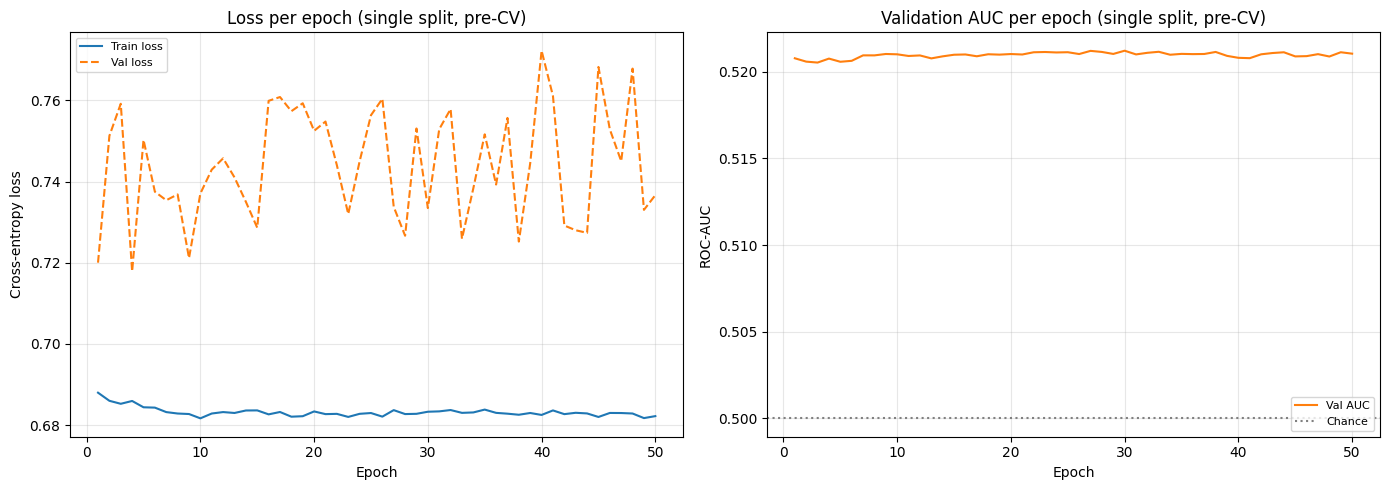

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(diag_result["history"]["train_loss"]) + 1)

# Left axis: train/val loss for the single split
axes[0].plot(epochs, diag_result["history"]["train_loss"], label="Train loss")
axes[0].plot(epochs, diag_result["history"]["val_loss"], label="Val loss", linestyle="--")
axes[0].set_title("Loss per epoch (single split, pre-CV)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right axis: validation AUC for the single split
axes[1].plot(epochs, diag_result["history"]["val_auc"], label="Val AUC", color="tab:orange")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].set_title("Validation AUC per epoch (single split, pre-CV)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(diag_dir/"pre_cv_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis of pre-CV diagnostic:

- Training loss started at 0.688 and fell only a little bit to 0.682 by epoch 10. It then stayed flat for the next 40 epochs, and never dropped meaningfully below the class weighted crosss entropy baseline of 0.69.

- Vlaidation loss was noisy and non-decreasing throughout all training. It oscillated between roughly 0.72 and 0.775, with the swings widening as training went on if anything. This is more consistent with the model failing to find much signal in the first place rather than classic overfitting, where training loss would keep falling while validation loss would shoot upwards.

- Validation AUC was essentially flat at 0.52 for the full 50 epochs, showing no learning trajectory at all.

At face value, this single split would suggest the model isn't learning anything useful. However, this diagnostic uses only one train/validation split of around 15 held-out subjects, and the tabular baseline results show this ohort produces substantial fold-to-fold variance in performance (Section 4a of the report). A single split can't distinguish a genuine ceiling in what the model can learn from a result that just isn't representative of this particular subject composition.

This is why the next move is to full 5-fold cross-validation. It establishes if the flat, close to chance pattern seen here is consistent across different folds or if it was just particular to this split.

## Run 5 fold CV

Motivated by the pre-CV diagnostic above, go to full 5-fold cross validation.

Create CV splits and results directory

In [ ]:
# Create CV splits (seed is needed to control split)
set_seed(config["seed"])
splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
print(f"Created {len(splits)} folds")

# This code creates timestamped results directory in Drive. Useful to see whats happening when
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will save to: {run_dir}")

# Save config used for this run
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

Created 5 folds
Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_20260831_184749


Run 5-fold CV

In [ ]:
# Create empty list to store fold results
fold_results = []

# This is the main CV loop. Each iteration trains and evaluates one fold end to end
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    # Use the defensive leakage check function created earlier to check for subject leakage
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    # For both train and validation datasets, record the number of pairs, subjects, and percentage of carriers
    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold to ensure independent training
    set_seed(config["seed"]+fold_idx)  # different seed per fold, but reproducible

    # These values come from the config
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Create train and validation loaders
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device, checkpoint_path=fold_dir/"best_model.pt",
        verbose=True)

    # Save the training history. This will be used to plot curves later on
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch. This will be used later for downstream metrics
    np.savez(
        fold_dir/"predictions.npz",
        y_true=result["best_metrics"]["y_true"],
        y_prob=result["best_metrics"]["y_prob"],
    )

    # Save fold-level metrics summary
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    # Collect the metrics and metadata into a dictionary for this particular fold
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    # Save the fold summary to disk. This allows for later analysis,
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)

    # Append to the running list created at the beginning. This can be used later for cross-fold aggregation.
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx+1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 5375 pairs, 62 subjects, 3025/5375 positive (56.3%)
Val: 1278 pairs, 15 subjects, 931/1278 positive (72.8%)
Epoch   1/200: train_loss=0.6880, val_loss=0.7199, val_auc=0.5208
Epoch   2/200: train_loss=0.6860, val_loss=0.7499, val_auc=0.5206
Epoch   3/200: train_loss=0.6853, val_loss=0.7579, val_auc=0.5206
Epoch   4/200: train_loss=0.6859, val_loss=0.7190, val_auc=0.5207
Epoch   5/200: train_loss=0.6844, val_loss=0.7505, val_auc=0.5206
Epoch   6/200: train_loss=0.6842, val_loss=0.7367, val_auc=0.5207
Epoch   7/200: train_loss=0.6833, val_loss=0.7343, val_auc=0.5208
Epoch   8/200: train_loss=0.6826, val_loss=0.7386, val_auc=0.5208
Epoch   9/200: train_loss=0.6826, val_loss=0.7184, val_auc=0.5209
Epoch  10/200: train_loss=0.6817, val_loss=0.7379, val_auc=0.5209
Epoch  11/200: train_loss=0.6829, val_loss=0.7438, val_auc=0.5208
Epoch  12/200: train_loss=0.6833, val_loss=0.7473, val_auc=0.5208
Epoch  13/200: train_loss=0.6829, val_loss=0.7433, val_auc=0.5207
Epoch  14/200: tr

Aggregate cross fold metrics

In [ ]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create some overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Create a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "n_subjects": len(subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs)-n_positive,
        "ratio_pos": n_positive/len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision   recall       f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.521222          27   0.769388 0.404941 0.530612     5375   1278                62              15
    1  0.468981           2   0.575668 0.445977 0.502591     5256   1397                61              16
    2  0.501424           2   0.570048 0.744949 0.645868     5337   1316                62              15
    3  0.683779          26   0.646396 0.401961 0.495682     5332   1321                62              15
    4  0.606646           2   0.489547 0.865948 0.625487     5312   1341                61              16

Cross-fold summary (n_folds=5)
AUC: 0.5564 +/- 0.0875
F1: 0.5600 +/- 0.0706
Precision: 0.6102 +/- 0.1049
Recall: 0.5728 +/- 0.2174

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_20260831_184749


Training curves plot

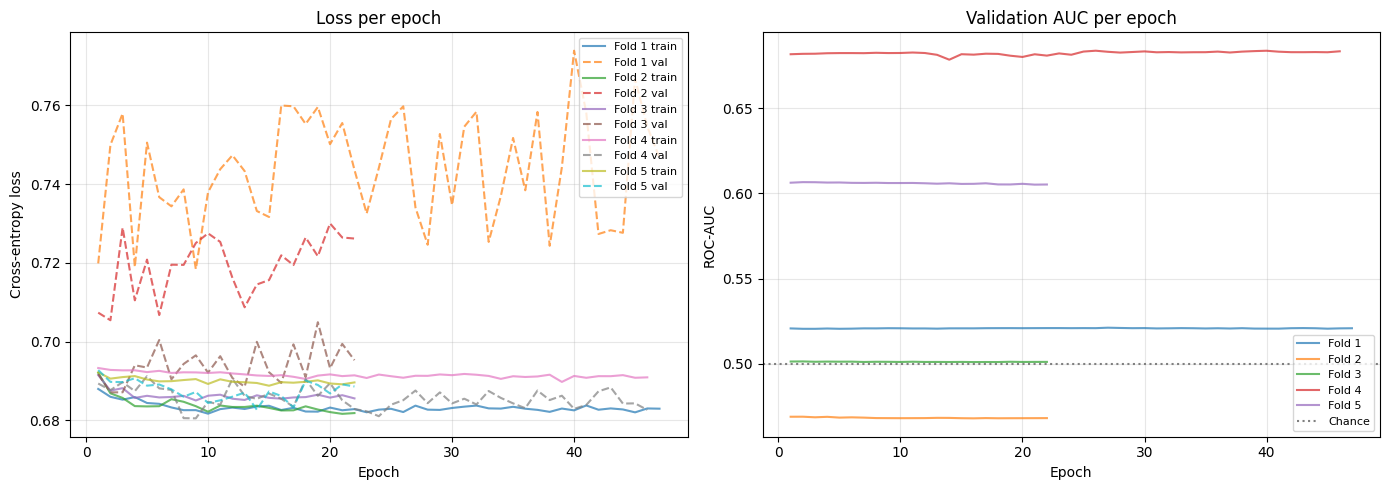

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save the graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Plot just showing best fold (for visual clarity)

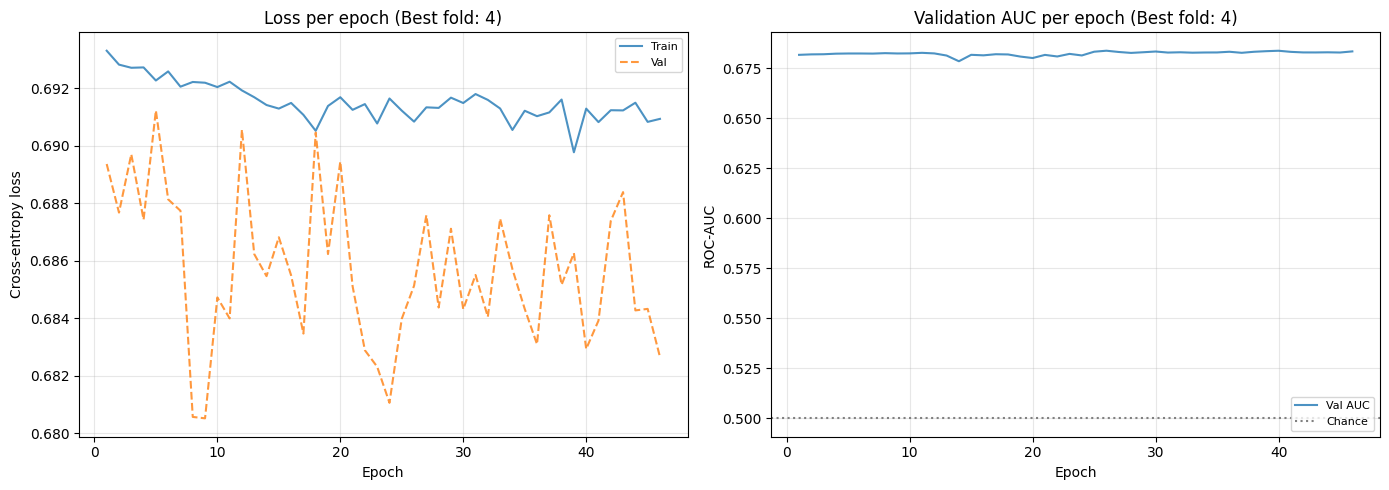

In [ ]:
# Identify the best fold (highest validation AUC)
best_fold_idx = int(summary_df.loc[summary_df["best_auc"].idxmax(), "fold"])

fold_dir = run_dir / f"fold_{best_fold_idx}"
with open(fold_dir / "history.json") as f:
    best_history = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(best_history["train_loss"]) + 1)

# Left: loss curves for the best fold only
axes[0].plot(epochs, best_history["train_loss"], label="Train", alpha=0.8)
axes[0].plot(epochs, best_history["val_loss"], label="Val", linestyle="--", alpha=0.8)
axes[0].set_title(f"Loss per epoch (Best fold: {best_fold_idx + 1})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Right: validation AUC curve for the best fold only
axes[1].plot(epochs, best_history["val_auc"], label="Val AUC", alpha=0.8)
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].set_title(f"Validation AUC per epoch (Best fold: {best_fold_idx + 1})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / "best_fold_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

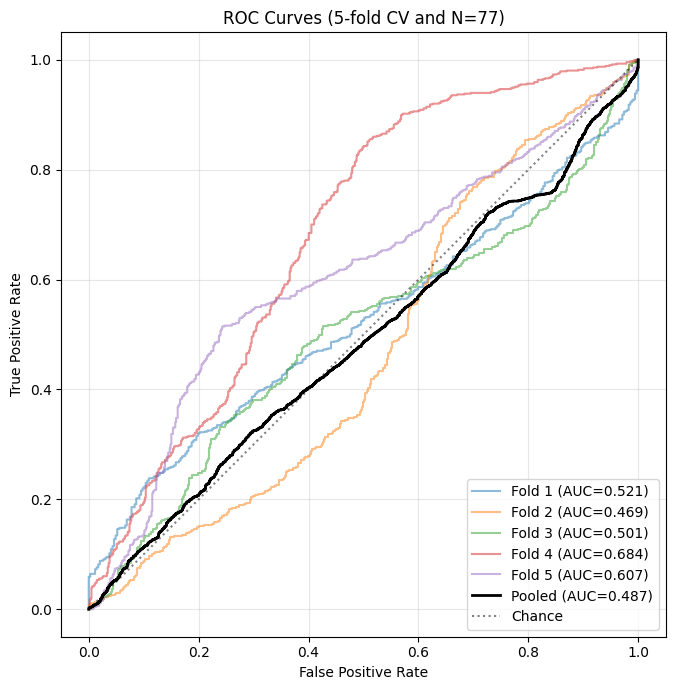

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx + 1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# Chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Title, labelss, legend and grid
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves (5-fold CV and N={len(subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save the graph
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Plot showing best fold's ROC curve

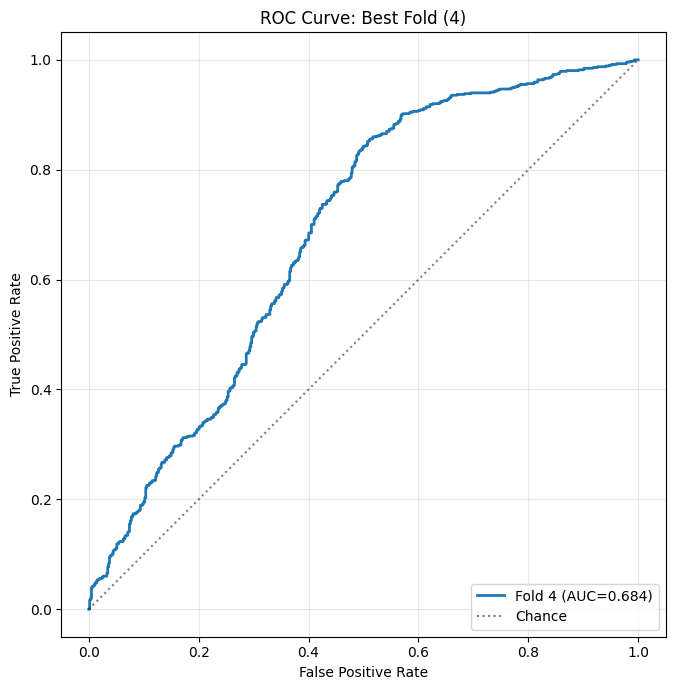

In [ ]:
# Reuses best_fold_idx from the cell above
preds = np.load(run_dir / f"fold_{best_fold_idx}" / "predictions.npz")
fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
best_fold_auc = roc_auc_score(preds["y_true"], preds["y_prob"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color="tab:blue", linewidth=2, label=f"Fold {best_fold_idx + 1} (AUC={best_fold_auc:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve: Best Fold ({best_fold_idx + 1})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(run_dir / "best_fold_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## SUMMARY OF FIRST GNN

This is a writeup of the first full cohort GNN training run on the PEARL-Neuro cohort using the 2 branch architecture with delta and alpha-2 frequency bands.

Some details of the model/training:

- Cohort = 77 subjects (46 carreirs and 31 non carriers)
- Class balance = 1.5:1 (carriers to non carriers)
- Architecture = 2 branch GCN with roughly 6300 parameters
- Cross-validation = 5 fold StartifiedGroupKFold, subject level splits
- Training = Adam optimiser, class-weighted cross-entropy and early stopping on validation AUC

The cross fold results are as follows:

| Fold | Best AUC | Best Epoch |
|------|----------|-----------|
| 1 | 0.5212 | 27 |
| 2 | 0.4690 | 2 |
| 3 | 0.5014 | 2 |
| 4 | 0.6843 | 26 |
| 5 | 0.6066 | 2 |

- Mean AUC = 0.556
- Standard deviation = 0.091
- Range = 0.469 to 0.684

The cross-fold pitcure is fairly mixed. The first three folds show chance level performance (around 0.50 on average) but folds 4-5 show weak to moderate signal (0.60-0.68). The best epochs in folds 2, 3 and 5 were at epoch 2, so there was no real training improvement, the random weights just happened to align. Only folds 1 to 4 show gradual improvement over the training process.

The fourth fold's stable 0.68 AUC across roughly 40 epochs shows the detection of genuine signal. Cross-fold variance is high (std = 0.091). This suggests that the model is detecting real but unstable patterns that are evry sensitive to which subjects appear in each validation fold.

For the purposes of comparison, the tabular baseline achieved an AUC of 0.830 compared to this GNN's mean-across-folds 0.556 AUC. Klepl et al. and Xu et al. had AUC in range 0.55-0.70, so my results are within the published literature range but below the tabular baseline.

There are probably a few reasons for the modest AUC. The effective training set is small. There are 60 training subjects per fold which provides limited generalisability, even though there are roughly 5,300 epoch-level examples per fold. There is also the fact that per-epoch aggregation might not be the most optimal. APOE effects most likely operate at the subject level abd per-epoch variability may be adding noise. It could also just ve that the signal is genuinely weak.Pre-symptomatic APOE classification from EEG is known to be a harder problem than dementia diagnosis going into this project. Was not expecting immaculate results, and perfect results aren't the point. The question is whether signal can be detected and if it can be improved using fusion methods and the tabualr data.

Next steps:

- Try some hyperparameter tuning (see the alzheimers-gnn-tuning file).
- Look into subject leve-aggregation. The wPLI matrices will be averaged across epochs per subject. This gives 1 graph per subject (77 total). This results in less training examples but each one captures subject-level connectivity patterns

The files thar are saved by running this file:

- `config.json` (hyperparameters used)
- `cross_fold_metrics.csv` (per-fold summary table)
- `summary.json` (top-level results)
- `training_curves.png` (loss and AUC trajectories)
- `roc_curves.png` (per-fold and pooled ROC)
- `fold_N/best_model.pt` (trained model weights)
- `fold_N/history.json` (per-epoch metrics)
- `fold_N/predictions.npz` (predictions at best epoch)
- `fold_N/metrics.json` (fold-level summary)